Loading Expert Models...
✓ Expert 1 (URL) loaded
✓ Expert 2 (Text) loaded
Loading Trained Gating Network...
✓ Gating Network loaded

✅ Complete MoE system loaded!


Loading test data...
✓ Test data loaded: 2000 samples

STARTING ROBUSTNESS TESTS

COMPREHENSIVE ROBUSTNESS TESTING

Testing on 500 samples

Testing: Character Typos
Noise 0.0: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.1: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.1: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.1: Acc=0.9660, Prec=0.9494, Rec=0.9548, F1=0.9521
Noise 0.2: Acc=0.9640, Prec=0.9492, Rec=0.9492, F1=0.9492
Noise 0.3: Acc=0.9600, Prec=0.9486, Rec=0.9379, F1=0.9432

Testing: Extra Spaces
Noise 0.0: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.1: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.2: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.3: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.4: Acc=0.9680, Prec=0.9497, Rec=0.9605, F1=0.9551
Noise 0.5

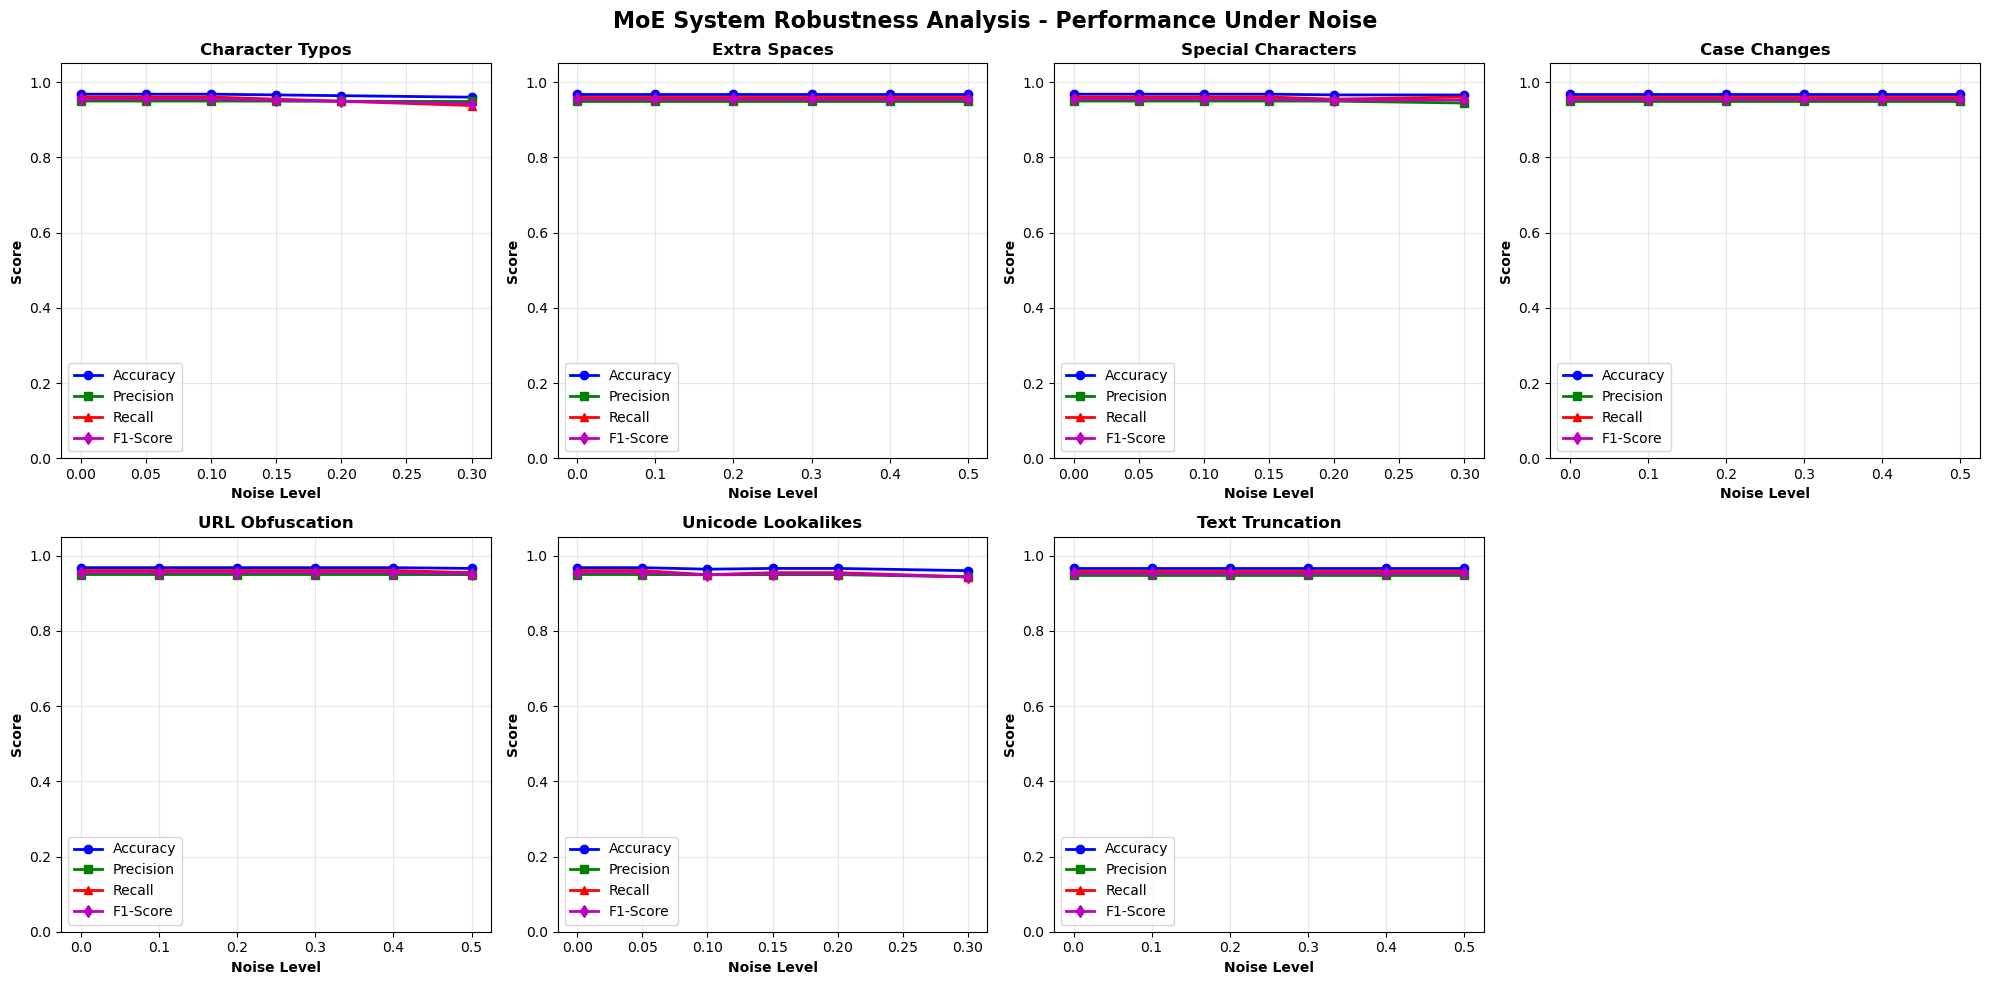


✅ Robustness testing complete!
📊 Check 'moe_robustness_analysis.png' for visualizations


In [2]:
# ============================================================================
# COMPLETE MOE SYSTEM WITH ROBUSTNESS TESTING
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from scipy.sparse import csr_matrix
import re
import random
import string
import matplotlib.pyplot as plt

# ============================================================================
# STEP 1: Define Required Classes
# ============================================================================

class URLFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, urls):
        urls = np.array(urls).reshape(-1)
        feats = np.array([
            [
                len(u),
                u.count('-'),
                u.count('@'),
                u.count('?'),
                u.count('='),
                u.count('.'),
                int(u.startswith("https")),
                int(u.count("//") > 1)
            ]
            for u in urls
        ])
        return csr_matrix(feats)

class GatingNetwork(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_experts=2):
        super(GatingNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_experts)
        self.softmax = nn.Softmax(dim=1)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        weights = self.softmax(x)
        return weights

# ============================================================================
# STEP 2: Load Expert Models
# ============================================================================

print("Loading Expert Models...")

URL_MODEL_PATH = r"C:\Users\angelo\Downloads\THESIS\URL_Expert-20251210T060216Z-1-001\URL_Expert\Notebook and Model\url_expert_1.pkl"
expert_1 = joblib.load(URL_MODEL_PATH)
print("✓ Expert 1 (URL) loaded")

TEXT_MODEL_PATH = r"C:\Users\angelo\Downloads\THESIS\distilbert_phishing_model"
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_PATH)
expert_2 = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_PATH)
expert_2.eval()
print("✓ Expert 2 (Text) loaded")

print("Loading Trained Gating Network...")
gating_net = GatingNetwork(input_size=8, hidden_size=64, num_experts=2)
gating_net.load_state_dict(torch.load('gating_network.pth'))
gating_net.eval()
print("✓ Gating Network loaded")

print("\n✅ Complete MoE system loaded!\n")

# ============================================================================
# STEP 3: Helper Functions
# ============================================================================

phrase_dict = {
    'urgent': 0.3, 'verify account': 0.5, 'suspended': 0.4,
    'click here': 0.3, 'confirm your': 0.4, 'congratulations': 0.3,
    'winner': 0.4, 'limited time': 0.3, 'act now': 0.3,
    'security alert': 0.5, 'claim': 0.3, 'prize': 0.3,
    'free': 0.2, 'bonus': 0.2,
}

def preprocess_text(text):
    if pd.isna(text) or text == "":
        return ""
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def calculate_phrase_score(text, phrase_dict):
    if not text:
        return 0.0
    text_lower = text.lower()
    score = 0.0
    for phrase, weight in phrase_dict.items():
        if phrase in text_lower:
            score += weight
    return min(score, 1.0)

def extract_gating_features(text, url, phrase_score):
    url_present = 1 if (url and not pd.isna(url) and url != "") else 0
    message_length = len(text.split()) if text else 0
    emoji_count = len(re.findall(r'[^\w\s,]', text)) if text else 0
    hashtag_count = text.count('#') if text else 0
    url_count = len(re.findall(r'http\S+', text)) if text else 0
    
    if text and len(text) > 0:
        capital_ratio = sum(1 for c in text if c.isupper()) / len(text)
    else:
        capital_ratio = 0.0
    
    embedding_summary = 0.0
    
    features = np.array([
        url_present, phrase_score, message_length, emoji_count,
        hashtag_count, url_count, capital_ratio, embedding_summary
    ], dtype=np.float32)
    
    return features

# ============================================================================
# STEP 4: NOISE INJECTION FUNCTIONS
# ============================================================================

class NoiseInjector:
    @staticmethod
    def add_typos(text, typo_rate=0.1):
        """Add random character typos"""
        if not text or len(text) == 0:
            return text
        
        words = text.split()
        noisy_words = []
        
        for word in words:
            if random.random() < typo_rate and len(word) > 2:
                typo_type = random.choice(['swap', 'insert', 'delete', 'replace'])
                word_list = list(word)
                pos = random.randint(0, len(word_list) - 1)
                
                if typo_type == 'swap' and len(word_list) > 1:
                    if pos < len(word_list) - 1:
                        word_list[pos], word_list[pos + 1] = word_list[pos + 1], word_list[pos]
                elif typo_type == 'insert':
                    word_list.insert(pos, random.choice(string.ascii_lowercase))
                elif typo_type == 'delete':
                    word_list.pop(pos)
                elif typo_type == 'replace':
                    word_list[pos] = random.choice(string.ascii_lowercase)
                
                word = ''.join(word_list)
            
            noisy_words.append(word)
        
        return ' '.join(noisy_words)
    
    @staticmethod
    def add_extra_spaces(text, space_rate=0.2):
        """Add random extra spaces"""
        if not text:
            return text
        
        result = []
        for char in text:
            result.append(char)
            if char == ' ' and random.random() < space_rate:
                result.append(' ')
        
        return ''.join(result)
    
    @staticmethod
    def add_special_chars(text, special_rate=0.15):
        """Add random special characters"""
        if not text:
            return text
        
        words = text.split()
        noisy_words = []
        
        for word in words:
            if random.random() < special_rate:
                special_chars = ['!', '@', '#', '$', '%', '&', '*']
                insert_pos = random.randint(0, len(word))
                word = word[:insert_pos] + random.choice(special_chars) + word[insert_pos:]
            noisy_words.append(word)
        
        return ' '.join(noisy_words)
    
    @staticmethod
    def change_case(text, case_rate=0.3):
        """Randomly change case of characters"""
        if not text:
            return text
        
        result = []
        for char in text:
            if char.isalpha() and random.random() < case_rate:
                result.append(char.swapcase())
            else:
                result.append(char)
        
        return ''.join(result)
    
    @staticmethod
    def obfuscate_url(url, obfuscation_rate=0.3):
        """Obfuscate URL with common phishing techniques"""
        if not url or random.random() > obfuscation_rate:
            return url
        
        techniques = [
            lambda u: u.replace('o', '0'),
            lambda u: u.replace('i', '1'),
            lambda u: u.replace('l', '1'),
            lambda u: u.replace('.com', '.c0m'),
        ]
        
        technique = random.choice(techniques)
        return technique(url)
    
    @staticmethod
    def add_unicode_lookalikes(text, unicode_rate=0.1):
        """Replace characters with Unicode lookalikes"""
        if not text:
            return text
        
        lookalikes = {
            'a': 'а', 'e': 'е', 'o': 'о', 'p': 'р', 'c': 'с',
        }
        
        result = []
        for char in text:
            lower_char = char.lower()
            if lower_char in lookalikes and random.random() < unicode_rate:
                replacement = lookalikes[lower_char]
                result.append(replacement.upper() if char.isupper() else replacement)
            else:
                result.append(char)
        
        return ''.join(result)
    
    @staticmethod
    def truncate_text(text, truncate_rate=0.1, truncate_amount=0.3):
        """Randomly truncate text"""
        if not text or random.random() > truncate_rate:
            return text
        
        truncate_length = int(len(text) * (1 - truncate_amount))
        return text[:truncate_length]

# ============================================================================
# STEP 5: ROBUSTNESS TESTER CLASS
# ============================================================================

class RobustnessTester:
    def __init__(self, expert_1, expert_2, gating_net, phrase_dict, tokenizer):
        self.expert_1 = expert_1
        self.expert_2 = expert_2
        self.gating_net = gating_net
        self.phrase_dict = phrase_dict
        self.tokenizer = tokenizer
        self.injector = NoiseInjector()
        self.results = {}
    
    def predict(self, text, url):
        """Make prediction using the MoE system"""
        text = preprocess_text(text)
        phrase_score = calculate_phrase_score(text, self.phrase_dict)
        
        # URL Expert
        if url and url.strip():
            try:
                url_df = pd.DataFrame({'url': [url]})
                url_probs = self.expert_1.predict_proba(url_df)[0]
            except:
                url_probs = np.array([0.5, 0.5])
        else:
            url_probs = np.array([0.5, 0.5])
        
        # Text Expert
        if text:
            try:
                inputs = self.tokenizer(text, return_tensors='pt', padding=True, 
                                      truncation=True, max_length=128)
                with torch.no_grad():
                    outputs = self.expert_2(**inputs)
                    text_probs = torch.softmax(outputs.logits, dim=1)[0].numpy()
            except:
                text_probs = np.array([0.5, 0.5])
        else:
            text_probs = np.array([0.5, 0.5])
        
        # Gating Network
        gating_features = extract_gating_features(text, url, phrase_score)
        gating_input = torch.FloatTensor(gating_features).unsqueeze(0)
        
        self.gating_net.eval()
        with torch.no_grad():
            expert_weights = self.gating_net(gating_input)
        
        final_probs = (expert_weights[0, 0].item() * url_probs + 
                      expert_weights[0, 1].item() * text_probs)
        
        return 1 if final_probs[1] > 0.5 else 0, max(final_probs)
    
    def test_noise_type(self, X_test, y_test, noise_func, noise_name, noise_levels=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5]):
        """Test model performance with varying noise levels"""
        print(f"\n{'='*70}")
        print(f"Testing: {noise_name}")
        print(f"{'='*70}")
        
        results = []
        
        for noise_level in noise_levels:
            predictions = []
            confidences = []
            
            for idx in range(len(X_test)):
                text = X_test.iloc[idx]['text']
                url = X_test.iloc[idx]['url']
                
                # Apply noise
                if 'url' in noise_name.lower():
                    url = noise_func(url, noise_level) if url else url
                else:
                    text = noise_func(text, noise_level) if text else text
                
                pred, conf = self.predict(text, url)
                predictions.append(pred)
                confidences.append(conf)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, predictions)
            precision = precision_score(y_test, predictions, zero_division=0)
            recall = recall_score(y_test, predictions, zero_division=0)
            f1 = f1_score(y_test, predictions, zero_division=0)
            
            results.append({
                'noise_level': noise_level,
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'avg_confidence': np.mean(confidences)
            })
            
            print(f"Noise {noise_level:.1f}: Acc={accuracy:.4f}, Prec={precision:.4f}, Rec={recall:.4f}, F1={f1:.4f}")
        
        self.results[noise_name] = results
        return results
    
    def run_comprehensive_test(self, X_test, y_test, sample_size=1000):
        """Run all robustness tests"""
        print("\n" + "="*80)
        print("COMPREHENSIVE ROBUSTNESS TESTING")
        print("="*80)
        
        # Sample data
        if len(X_test) > sample_size:
            indices = np.random.choice(len(X_test), sample_size, replace=False)
            X_sample = X_test.iloc[indices].reset_index(drop=True)
            y_sample = y_test.iloc[indices].reset_index(drop=True)
        else:
            X_sample = X_test.reset_index(drop=True)
            y_sample = y_test.reset_index(drop=True)
        
        print(f"\nTesting on {len(X_sample)} samples")
        
        # Run all noise tests
        self.test_noise_type(X_sample, y_sample, self.injector.add_typos, 
                            "Character Typos", [0.0, 0.05, 0.1, 0.15, 0.2, 0.3])
        
        self.test_noise_type(X_sample, y_sample, self.injector.add_extra_spaces,
                            "Extra Spaces", [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
        
        self.test_noise_type(X_sample, y_sample, self.injector.add_special_chars,
                            "Special Characters", [0.0, 0.05, 0.1, 0.15, 0.2, 0.3])
        
        self.test_noise_type(X_sample, y_sample, self.injector.change_case,
                            "Case Changes", [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
        
        self.test_noise_type(X_sample, y_sample, self.injector.obfuscate_url,
                            "URL Obfuscation", [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
        
        self.test_noise_type(X_sample, y_sample, self.injector.add_unicode_lookalikes,
                            "Unicode Lookalikes", [0.0, 0.05, 0.1, 0.15, 0.2, 0.3])
        
        self.test_noise_type(X_sample, y_sample, self.injector.truncate_text,
                            "Text Truncation", [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
        
        return self.results
    
    def generate_robustness_report(self):
        """Generate comprehensive robustness analysis"""
        print("\n" + "="*80)
        print("ROBUSTNESS ANALYSIS SUMMARY")
        print("="*80)
        
        overall_scores = []
        
        for noise_type, results in self.results.items():
            df = pd.DataFrame(results)
            
            baseline_acc = df.iloc[0]['accuracy']
            max_noise_acc = df.iloc[-1]['accuracy']
            degradation = ((baseline_acc - max_noise_acc) / baseline_acc) * 100 if baseline_acc > 0 else 0
            
            print(f"\n{noise_type}:")
            print(f"  Baseline Accuracy: {baseline_acc:.4f}")
            print(f"  Max Noise Accuracy: {max_noise_acc:.4f}")
            print(f"  Degradation: {degradation:.2f}%")
            
            if degradation < 5:
                status = "✅ EXCELLENT - Highly robust"
                score = 100
            elif degradation < 10:
                status = "✅ GOOD - Robust"
                score = 85
            elif degradation < 20:
                status = "⚠️ ACCEPTABLE - Moderately robust"
                score = 70
            else:
                status = "❌ POOR - Low robustness"
                score = 50
            
            print(f"  Status: {status}")
            overall_scores.append(score)
        
        avg_robustness = np.mean(overall_scores)
        print(f"\n{'='*80}")
        print(f"OVERALL ROBUSTNESS SCORE: {avg_robustness:.1f}/100")
        print(f"{'='*80}")
    
    def plot_robustness_results(self, save_path='robustness_analysis.png'):
        """Visualize robustness test results"""
        n_tests = len(self.results)
        n_cols = 4
        n_rows = (n_tests + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        axes = axes.flatten()
        
        fig.suptitle('MoE System Robustness Analysis - Performance Under Noise', 
                     fontsize=16, fontweight='bold')
        
        for idx, (noise_type, results) in enumerate(self.results.items()):
            df = pd.DataFrame(results)
            ax = axes[idx]
            
            ax.plot(df['noise_level'], df['accuracy'], 'b-o', label='Accuracy', linewidth=2)
            ax.plot(df['noise_level'], df['precision'], 'g-s', label='Precision', linewidth=2)
            ax.plot(df['noise_level'], df['recall'], 'r-^', label='Recall', linewidth=2)
            ax.plot(df['noise_level'], df['f1'], 'm-d', label='F1-Score', linewidth=2)
            
            ax.set_xlabel('Noise Level', fontweight='bold')
            ax.set_ylabel('Score', fontweight='bold')
            ax.set_title(noise_type, fontweight='bold')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='best')
            ax.set_ylim([0, 1.05])
        
        for idx in range(len(self.results), len(axes)):
            axes[idx].set_visible(False)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\n📊 Robustness plot saved to: {save_path}")
        plt.show()

# ============================================================================
# STEP 6: LOAD TEST DATA
# ============================================================================

print("\nLoading test data...")

# Load datasets
df_url = pd.read_csv(r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\url_dataset_combined_1.csv")
df_url = df_url[['url', 'label']].copy()
df_url['text'] = ""

try:
    df_text = pd.read_csv(r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv")
except:
    df_text = pd.read_csv(r"C:\Users\angelo\Downloads\THESIS\Dataset_5971\Dataset_100k.csv", 
                         encoding='latin-1')

df_text = df_text[['label', 'text']].copy()
df_text['url'] = ""

# Combine and sample
df_combined = pd.concat([df_url, df_text], ignore_index=True).dropna()
df_test = df_combined.sample(n=min(2000, len(df_combined)), random_state=42)

X_test = df_test[['text', 'url']]
y_test = df_test['label']

print(f"✓ Test data loaded: {len(X_test)} samples")

# ============================================================================
# STEP 7: RUN ROBUSTNESS TESTS
# ============================================================================

print("\n" + "="*80)
print("STARTING ROBUSTNESS TESTS")
print("="*80)

# Initialize tester
tester = RobustnessTester(expert_1, expert_2, gating_net, phrase_dict, tokenizer)

# Run tests
results = tester.run_comprehensive_test(X_test, y_test, sample_size=500)

# Generate report
tester.generate_robustness_report()

# Create visualizations
tester.plot_robustness_results('moe_robustness_analysis.png')

print("\n✅ Robustness testing complete!")
print("📊 Check 'moe_robustness_analysis.png' for visualizations")